In [141]:
import pandas as pd
import numpy as np
from sklearn import linear_model
import matplotlib.pyplot as plt

In [143]:
fashion_df = pd.read_csv("./data/fashion_data.csv")
fashion_df["Order Date"] = pd.to_datetime(fashion_df["Order Date"]) # Formating Order date back to Datetime dtype, in read_csv you cant set column to datetime so need to do manually
fashion_df.set_index("Order Date", inplace=True)
fashion_df.drop(columns=["Unnamed: 0"], inplace=True)

fashion_df.head()

,Shipping Address State,Revenue,Survey ResponseID,ppt,tmax,tmin,tavg
Order Date,,,,,,,
2017-01-01,AL,0.0,NaN,25.626,13.849,4.712,9.280
2017-01-01,AR,0.0,NaN,1.999,10.667,4.430,7.548
2017-01-01,AZ,0.0,NaN,4.824,9.969,4.154,7.061
2017-01-01,CA,0.0,NaN,3.760,9.559,0.137,4.848
2017-01-01,CO,0.0,NaN,0.385,2.787,-9.496,-3.354


In [125]:
# Filter for one state 
# Arrange by date 
# Calc temp - temp(t=-365)
# Calc first oder difference in revenue
# for each state filter out days which were only used to calc temp-365 / meaning the day bevore revenue was recorded

In [144]:
df_one_state_filter = fashion_df["Shipping Address State"] == "AR"
df_one_state = fashion_df[df_one_state_filter].copy()

### Create 365 day laged temperature column

In [145]:
df_one_state["Temp_No_Season"] = df_one_state["tavg"] - df_one_state["tavg"].shift(365)
df_one_state["Temp_No_Season"] = df_one_state["Temp_No_Season"].round(3)

### Create 365 laged rain column

In [146]:
df_one_state["Rain_No_Season"] = df_one_state["ppt"] - df_one_state["ppt"].shift(365)
df_one_state["Rain_No_Season"] = df_one_state["Rain_No_Season"].round(3)

### Create first order diff for Revenue

In [147]:
first_order_diff = [0]

for j in range(1,len(df_one_state)): 
    first_order_diff.append(df_one_state["Revenue"][j] - df_one_state["Revenue"][j-1])

df_one_state["first_order_diff_Revenue"] = first_order_diff
df_one_state["first_order_diff_Revenue"] = df_one_state["first_order_diff_Revenue"].round(4)

### Remove days wich were only used for temp calculations

In [148]:
df_one_state = df_one_state.iloc[365:, :]

#### Linear regression for: First order difference Revenue ~ 365 lag Temp + 1 day lag first order difference Revenue

In [151]:
df_one_state['Time'] = np.arange(len(df_one_state))

,Shipping Address State,Revenue,Survey ResponseID,ppt,tmax,tmin,tavg,Temp_No_Season,Rain_No_Season,first_order_diff_Revenue,Time
Order Date,,,,,,,,,,,
2018-01-01,AR,0.0,NaN,0.001,-2.998,-12.274,-7.636,-15.184,-1.998,0.0,0
2018-01-02,AR,0.0,NaN,0.000,-5.223,-12.965,-9.094,-16.861,-2.611,0.0,1
2018-01-03,AR,0.0,NaN,0.001,-4.775,-12.074,-8.424,-19.731,-14.006,0.0,2
2018-01-04,AR,0.0,NaN,0.000,2.883,-9.736,-3.427,-9.445,-0.023,0.0,3
2018-01-05,AR,0.0,NaN,0.000,2.840,-8.821,-2.990,-3.322,0.000,0.0,4


In [153]:
X = df_one_state[["Time", "Temp_No_Season", "first_order_diff_Revenue", "Rain_No_Season"]]
y = df_one_state['Revenue']

ols = linear_model.LinearRegression()
model = ols.fit(X, y)

#https://www.kaggle.com/code/ryanholbrook/linear-regression-with-time-series
response = model.predict(X, index=X.index)

r2 = model.score(X, y)
print(r2)

TypeError: LinearModel.predict() got an unexpected keyword argument 'index'

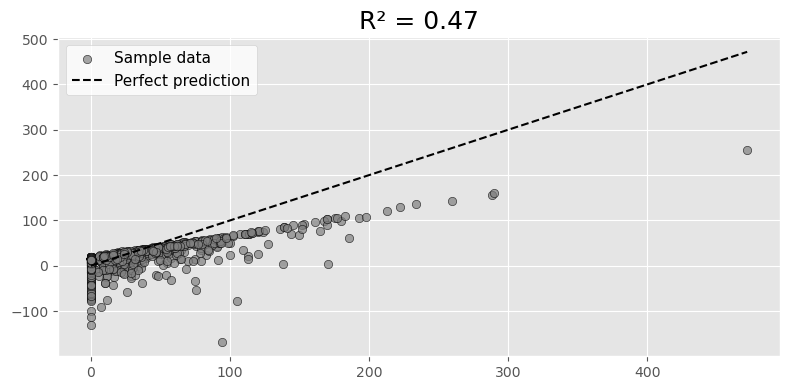

In [ ]:
r2 = model.score(X, y)

# Get the predicted values
y_pred = model.predict(X)

plt.style.use('default')
plt.style.use('ggplot')

fig, ax = plt.subplots(figsize=(8, 4))


# Option 2: If you want to plot predicted vs actual
ax.scatter(y, y_pred, edgecolor='k', facecolor='grey', alpha=0.7, label='Sample data')
ax.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', label='Perfect prediction')

ax.legend(facecolor='white', fontsize=11)
ax.set_title(f'R² = {r2:.2f}', fontsize=18)

fig.tight_layout()
plt.show()

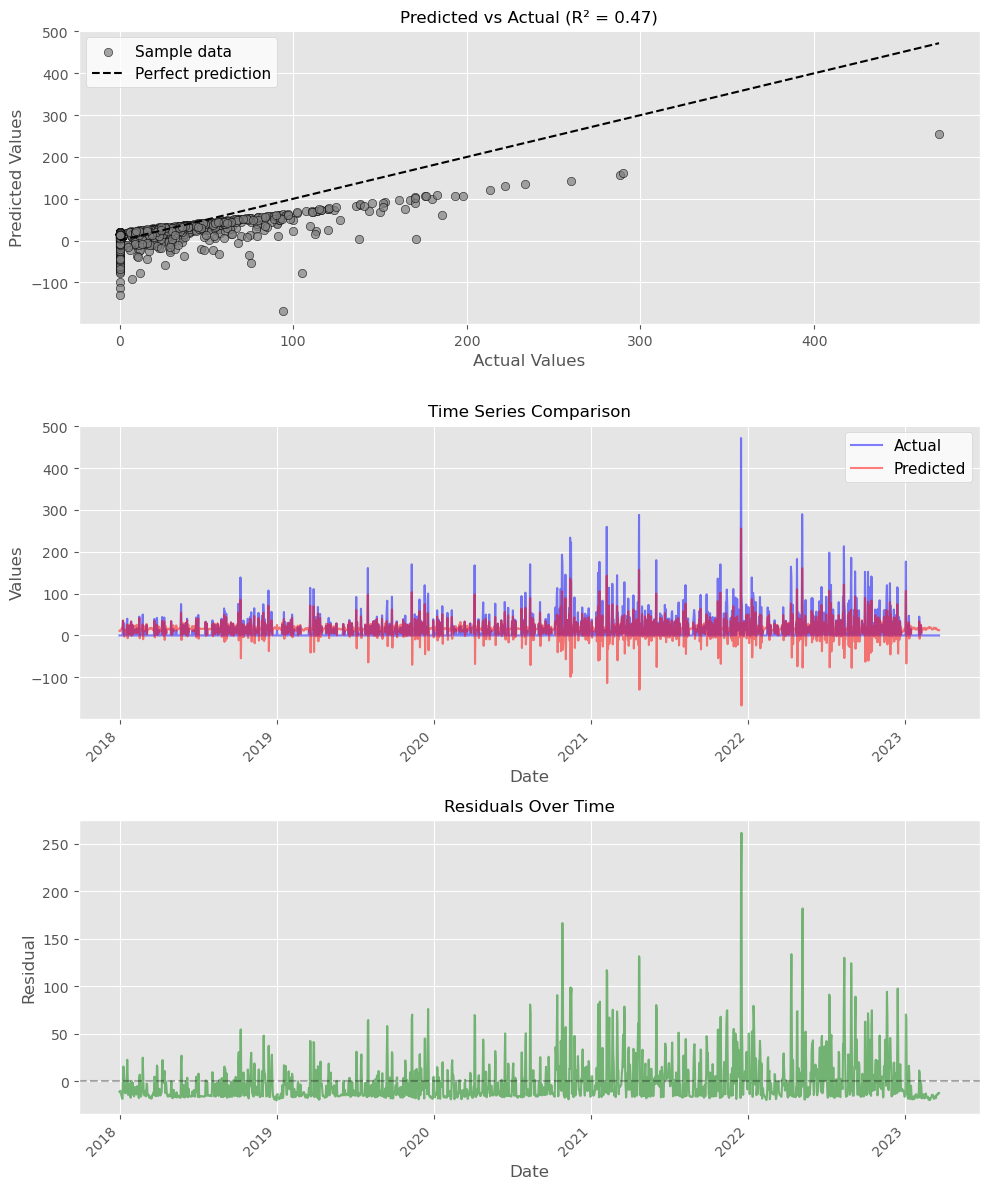

In [115]:
# Create figure with three subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12))

# First subplot: Predicted vs Actual (scatter)
ax1.scatter(y, y_pred, edgecolor='k', facecolor='grey', alpha=0.7, label='Sample data')
ax1.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', label='Perfect prediction')
ax1.legend(facecolor='white', fontsize=11)
ax1.set_title(f'Predicted vs Actual (R² = {r2:.2f})', fontsize=12)
ax1.set_xlabel('Actual Values')
ax1.set_ylabel('Predicted Values')

# Second subplot: Time series comparison
dates = df_one_state.index  # Assuming your dates are in the index
ax2.plot(dates, y, 'b-', alpha=0.5, label='Actual')
ax2.plot(dates, y_pred, 'r-', alpha=0.5, label='Predicted')
ax2.legend(facecolor='white', fontsize=11)
ax2.set_title('Time Series Comparison', fontsize=12)
ax2.set_xlabel('Date')
ax2.set_ylabel('Values')

# Third subplot: Residuals over time
residuals = y - y_pred
ax3.plot(dates, residuals, 'g-', alpha=0.5)
ax3.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax3.set_title('Residuals Over Time', fontsize=12)
ax3.set_xlabel('Date')
ax3.set_ylabel('Residual')

# Rotate date labels for better readability
plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')
plt.setp(ax3.get_xticklabels(), rotation=45, ha='right')

fig.tight_layout()
plt.show()